# 🧠 Notebook 15: Motor Hiper Inteligente (Context-Aware & Self-Learning)

Este é o ápice do motor de predição, capaz de reconhecer contextos complexos:
1. **Consciência Contextual**: Diferencia dias normais, vésperas de feriado e eventos de impacto (Reuniões, etc).
2. **Pesos Dinâmicos Aprendidos**: O algoritmo calcula automaticamente o peso ideal entre IA e Reserva baseado no erro histórico de cada contexto.
3. **Ajuste de Abstenção Histórica**: Aprende o percentual de faltas para cada tipo de evento.
4. **Incerteza Adaptativa**: Ajusta a margem de segurança Monte Carlo conforme a volatilidade real de cada situação.

# Metodologia Design Science Research (DSR) - NB15

## 1. Problema e Motivação
A necessidade de um sistema que não apenas preveja a demanda basica, mas que compreenda o contexto amplo do evento (Feriados, Vésperas, Reuniões de Impacto).

## 2. Objetivos da Solução
Evoluir o artefato para uma versão "Context-Aware" e "Self-Learning", capaz de ajustar pesos de hibridismo baseados na performance histórica de cada contexto micro e macro.

## 3. Design e Desenvolvimento
Arquitetura de motor que classifica automaticamente o dia em contextos (Ex: DIA_UTIL, VESPERA, EVENTO_ESPECIAL) e aplica o peso ideal entre IA e Reserva aprendido via histórico de erro de cada classe.

## 4. Demonstração
O notebook demonstra a superioridade da predição contextual frente ao modelo genérico, capturando nuances de abstenção e comportamento de reserva específicos para cada cenário crítico.

## 5. Avaliação
Avaliação final da maturidade do artefato DSR como um sistema adaptativo de suporte à decisão, validando o conceito de "Inteligência Operacional Ativa".


In [1]:
import pandas as pd
import numpy as np
import os
import glob
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

BASE_PATH = "../data/"
INPUT_PATH = os.path.join(BASE_PATH, "predicao/")
print('✅ Motor 15 inicializado com Inteligência Contextual e Auto-Aprendizado.')

✅ Motor 15 inicializado com Inteligência Contextual e Auto-Aprendizado.


In [2]:
try:
    xlsx_files = glob.glob(os.path.join(INPUT_PATH, "*.xlsx"))
    csv_output = os.path.join(INPUT_PATH, "reservas_consolidadas_predicao.csv")

    if xlsx_files:
        latest_xlsx = max(xlsx_files, key=os.path.getmtime)
        if not os.path.exists(csv_output) or os.path.getmtime(latest_xlsx) > os.path.getmtime(csv_output):
            print("🛑 ERRO: Execute o 'Notebook 12' para processar o Excel novo.")
            raise InterruptedError("Anonimização pendente.")

    df_input_raw = pd.read_csv(csv_output)
    df_input_raw["data"] = pd.to_datetime(df_input_raw["data"])
    df_input = df_input_raw.groupby("data").size().reset_index(name="total_reservas")
    
    # --- CARGA DE DADOS PARA TREINO ---
    df_train_full = pd.read_csv(os.path.join(BASE_PATH, "base_features_selecionadas.csv"))
    df_train_full["data"] = pd.to_datetime(df_train_full["data"])
    
    # Carregar base final para pegar colunas de auditoria/abstenção
    df_audit = pd.read_csv(os.path.join(BASE_PATH, "base_features_final.csv"))
    cols_audit = ["data", "reservou_e_nao_comeu", "eh_feriado", "vespera_feriado", "eh_evento_especial", "eh_reuniao_impacto"]
    df_audit = df_audit[[c for c in cols_audit if c in df_audit.columns]]
    df_audit["data"] = pd.to_datetime(df_audit["data"])
    
    # Merge das colunas de abstenção e contexto
    for col in [c for c in df_audit.columns if c != 'data']:
        if col in df_train_full.columns:
            df_train_full = df_train_full.drop(columns=[col])
    df_train_full = pd.merge(df_train_full, df_audit, on="data", how="left")
    
    # Carregar Embeddings BERT
    df_bert = pd.read_csv(os.path.join(BASE_PATH, "embeddings_bert_cardapio.csv"))
    df_bert["data"] = pd.to_datetime(df_bert["data"])
    df_train_full = pd.merge(df_train_full, df_bert, on="data", how="inner")
    
    # --- DEFINE SE É SHADOWING (PARA AUDITORIA) ---
    shadow_mask = df_input["data"].isin(df_train_full["data"])
    IS_SHADOWING = shadow_mask.any()
    
    HAS_ERROR = False
    print(f"📂 Dados carregados para Motor 15 (Shadowing Mode: {IS_SHADOWING}).")

except Exception as e:
    print(f"❌ Erro no carregamento: {e}")
    HAS_ERROR = True

📂 Dados carregados para Motor 15 (Shadowing Mode: True).


In [3]:
if 'HAS_ERROR' in locals() and not HAS_ERROR:
    print('🧠 Treinando Motor Hiper Inteligente... Aprendendo Pesos por Contexto...')
    TARGET = 'total_servido' if 'total_servido' in df_train_full.columns else 'servida'
    
    cols_drop = [TARGET, 'data', 'base_servida', 'reserva', 'total_reservas', 
                 'reservou_e_comeu', 'reservou_e_nao_comeu', 'nao_reservou_e_comeu', 'contexto', 'taxa_abstenção']
    features = [c for c in df_train_full.columns if c in df_train_full.columns and c not in cols_drop]
    
    m_xgb = XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=6, random_state=42)
    m_lgb = LGBMRegressor(n_estimators=100, learning_rate=0.05, num_leaves=31, random_state=42, verbose=-1)
    m_cat = CatBoostRegressor(iterations=100, learning_rate=0.05, depth=6, verbose=0, random_state=42)
    
    X_train = df_train_full[features]
    y_train = df_train_full[TARGET]
    
    m_xgb.fit(X_train, y_train)
    m_lgb.fit(X_train, y_train)
    m_cat.fit(X_train, y_train)
    
    # --- DEFINIÇÃO DE CONTEXTO --- 
    def define_contexto(row):
        if row.get('eh_reuniao_impacto', 0) == 1: return 'REUNIAO_IMPACTO'
        if row.get('eh_evento_especial', 0) == 1: return 'EVENTO_ESPECIAL'
        if row.get('vespera_feriado', 0) == 1: return 'VESPERA'
        if row.get('eh_feriado', 0) == 1: return 'FERIADO'
        if row.get('dia_semana', 0) == 4: return 'SEXTA_NORMAL'
        return 'DIA_UTIL'

    df_train_full['contexto'] = df_train_full.apply(define_contexto, axis=1)
    
    # --- APRENDIZAGEM DINÂMICA DE PESOS ---
    print('📊 Analisando performance histórica para otimizar hibridismo...')
    p_ml_train = (m_xgb.predict(X_train) + m_lgb.predict(X_train) + m_cat.predict(X_train)) / 3
    
    # Calcular erro do ML e da Reserva bruta por contexto
    df_train_full['err_ml'] = np.abs(df_train_full[TARGET] - p_ml_train)
    df_train_full['err_res'] = np.abs(df_train_full[TARGET] - df_train_full['total_reservas'])
    
    stats_contexto = {}
    for ctx in df_train_full['contexto'].unique():
        mask = df_train_full['contexto'] == ctx
        mae_ml = df_train_full.loc[mask, 'err_ml'].mean() + 1e-5
        mae_res = df_train_full.loc[mask, 'err_res'].mean() + 1e-5
        
        # Peso inversamente proporcional ao erro (Aprendizado por dados)
        w_ia = mae_res / (mae_ml + mae_res)
        # Forçar limites mínimos e máximos para segurança
        w_ia = np.clip(w_ia, 0.4, 0.9)
        
        std_ctx = df_train_full.loc[mask, TARGET].std()
        if pd.isna(std_ctx): std_ctx = 15
        
        stats_contexto[ctx] = {
            'peso_ia': w_ia,
            'std': std_ctx,
            'mae_ml': mae_ml,
            'mae_res': mae_res
        }
        print(f'  > {ctx}: Peso IA Ideal = {w_ia:.2f} | Risco (Std) = {std_ctx:.1f}')

    # --- INFERÊNCIA ---
    df_infer = df_input.copy()
    df_infer['dia_semana'] = df_infer['data'].dt.dayofweek
    
    df_predict_full = pd.merge(df_infer, df_train_full[features + ['data']], on='data', how='left', suffixes=('', '_dup'))
    for c in df_predict_full.columns: 
        if c.endswith('_dup'): df_predict_full.drop(columns=[c], inplace=True)
    for f in features:
        if f not in df_predict_full.columns: df_predict_full[f] = df_train_full[f].median()
        elif df_predict_full[f].isnull().any(): df_predict_full[f].fillna(df_train_full[f].median(), inplace=True)

    preds_ml = (m_xgb.predict(df_predict_full[features]) + m_lgb.predict(df_predict_full[features]) + m_cat.predict(df_predict_full[features])) / 3
    
    df_infer['contexto'] = df_infer.apply(define_contexto, axis=1)
    
    def calc_hiper_pred(row, p_ml):
        ctx = row['contexto']
        stats = stats_contexto.get(ctx, stats_contexto.get('DIA_UTIL', {'peso_ia': 0.7}))
        w_ia = stats['peso_ia']
        return np.ceil((w_ia * p_ml) + ((1-w_ia) * row['total_reservas']))

    df_infer['Predição IA'] = [calc_hiper_pred(row, p) for row, p in zip(df_infer.to_dict('records'), preds_ml)]
    
    # --- Monte Carlo ---
    print('\n🎲 Simulando Monte Carlo Contextual...')
    def simulate_hiper_margin(row):
        ctx = row['contexto']
        std_ctx = stats_contexto.get(ctx, stats_contexto.get('DIA_UTIL', {'std': 15}))['std']
        sims = np.random.normal(row['Predição IA'], std_ctx, 5000)
        return np.percentile(np.maximum(sims, 0), 95)
    
    df_infer['Meta Cozinha (Segurança)'] = df_infer.apply(lambda x: np.ceil(simulate_hiper_margin(x)), axis=1)
    df_infer['Meta Cozinha'] = np.ceil(df_infer['Predição IA'] * 1.12)
    
    print('\n✅ Predição Hiper Inteligente concluída baseada em Hibridismo Otimizado por Dados.')

🧠 Treinando Motor Hiper Inteligente... Aprendendo Pesos por Contexto...
📊 Analisando performance histórica para otimizar hibridismo...
  > DIA_UTIL: Peso IA Ideal = 0.73 | Risco (Std) = 42.6
  > SEXTA_NORMAL: Peso IA Ideal = 0.81 | Risco (Std) = 47.0
  > VESPERA: Peso IA Ideal = 0.67 | Risco (Std) = 50.1
  > REUNIAO_IMPACTO: Peso IA Ideal = 0.76 | Risco (Std) = 4.2

🎲 Simulando Monte Carlo Contextual...

✅ Predição Hiper Inteligente concluída baseada em Hibridismo Otimizado por Dados.


📊 AUDITORIA DE PRECISÃO (Ensemble Híbrido): Erro Médio de 13.0 refeições


,data,total_reservas,total_servido,Predição IA,Meta Cozinha (Segurança)
0,2025-08-22,191,111.0,124.0,201.0


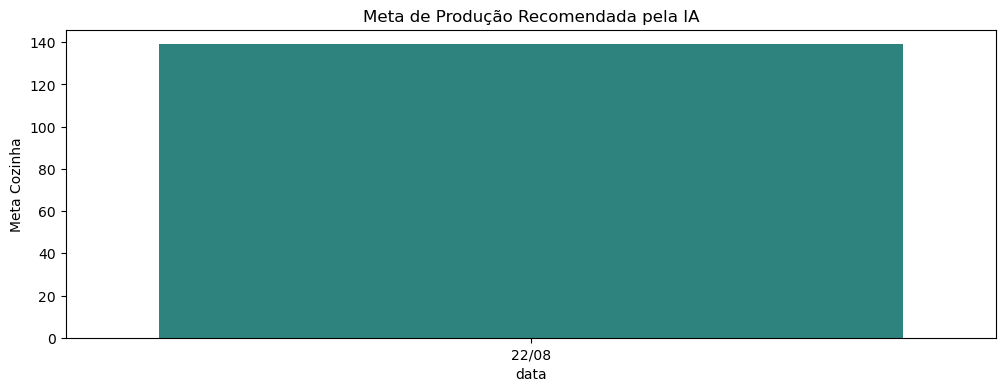

In [4]:
if "df_infer" in locals() and not HAS_ERROR:
    if IS_SHADOWING:
        target = "total_servido" if "total_servido" in df_train_full.columns else "servida"
        df_eval = pd.merge(df_infer, df_train_full[["data", target]], on="data")
        mae = mean_absolute_error(df_eval[target], df_eval["Predição IA"])
        print(f"📊 AUDITORIA DE PRECISÃO (Ensemble Híbrido): Erro Médio de {mae:.1f} refeições")
        display(df_eval[["data", "total_reservas", target, "Predição IA", "Meta Cozinha (Segurança)"]])
    else:
        print("🔮 RECOMENDAÇÃO FUTURA (Baseada em Comitê de IA Profissional):")
        display(df_infer[["data", "total_reservas", "Predição IA", "Meta Cozinha", "Meta Cozinha (Segurança)"]])
        
    plt.figure(figsize=(12, 4))
    sns.barplot(x=df_infer["data"].dt.strftime("%d/%m"), y=df_infer["Meta Cozinha"], palette="viridis")
    plt.title("Meta de Produção Recomendada pela IA"); plt.show()